In this notebook, I'll implement the k-means clustering algorithm on synthetically generated data. Let's import the necessary libraries.

In [1]:
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np

pd.options.display.float_format = '{:,.3f}'.format
pd.set_option('display.max_columns', None)

We generate three synthetic clusters, each containing 200 observations. For each cluster, age and spending score are independently sampled from normal distributions with cluster-specific means and standard deviations.

In [2]:
obs_nmbr = 200

cluster1 = np.random.normal(loc=[25, 40], scale=[5, 10], size=(obs_nmbr, 2))
cluster2 = np.random.normal(loc=[40, 80], scale=[6, 5], size=(obs_nmbr, 2))
cluster3 = np.random.normal(loc=[60, 20], scale=[5, 5], size=(obs_nmbr, 2))

age, score = int(cluster1[:1][0][0]), int(cluster1[:1][0][1])

print(f'As an example, this hypothetical person is \
{age} years old and a spending score of {score}.')

As an example, this hypothetical person is 26 years old and a spending score of 36.


We combine the three clusters and create a dataframe with proper column names.

In [3]:
# combine
data = np.vstack([cluster1, cluster2, cluster3])

# DataFrame
df = pd.DataFrame(data, columns=["Age", "SpendingScore"])

df.sample(2)

,Age,SpendingScore
461,55.389,18.905
93,21.610,30.964


---
Let's visualize the dataset in 2D.

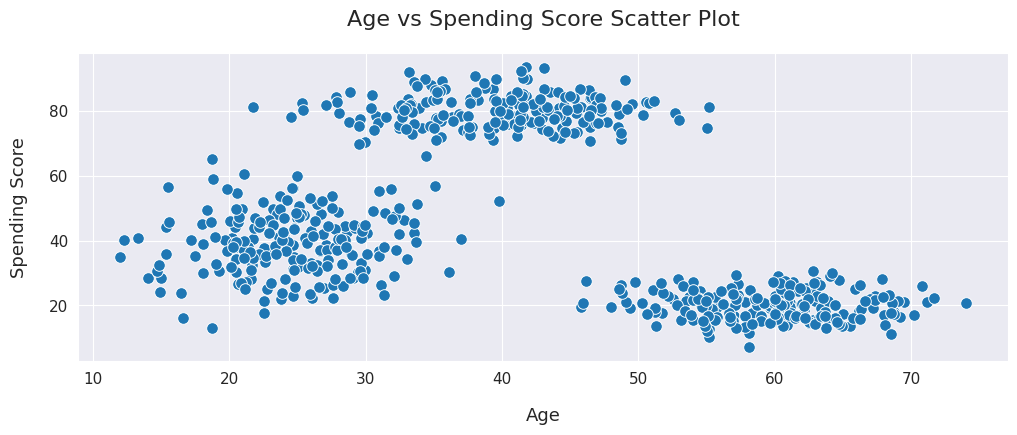

In [4]:
plt.figure(figsize=(12, 4))
sns.set_style("darkgrid")

sns.scatterplot(
    data=df,
    x="Age",
    y="SpendingScore",
    s=70
    
)

plt.title("Age vs Spending Score Scatter Plot", fontsize=16, pad=20)
plt.xlabel("Age", fontsize=13, labelpad=15)
plt.ylabel("Spending Score", fontsize=13, labelpad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

In [26]:
# Instantiating the KMeans class with n_clusters and random_state parameters
spectral = SpectralClustering(n_clusters=3, affinity="nearest_neighbors",
                              n_neighbors=5, assign_labels="discretize", 
                              random_state=42)

# Call the fit bound method of the KMeans instance to fit the model 
spectral.fit(df)

/data/miniconda3/envs/analitik-crm/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:260: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


SpectralClustering(affinity='nearest_neighbors', assign_labels='discretize',
                   n_clusters=3, n_neighbors=5, random_state=42)

let's visualize the dataset in 2D and color the each point according to their cluster.

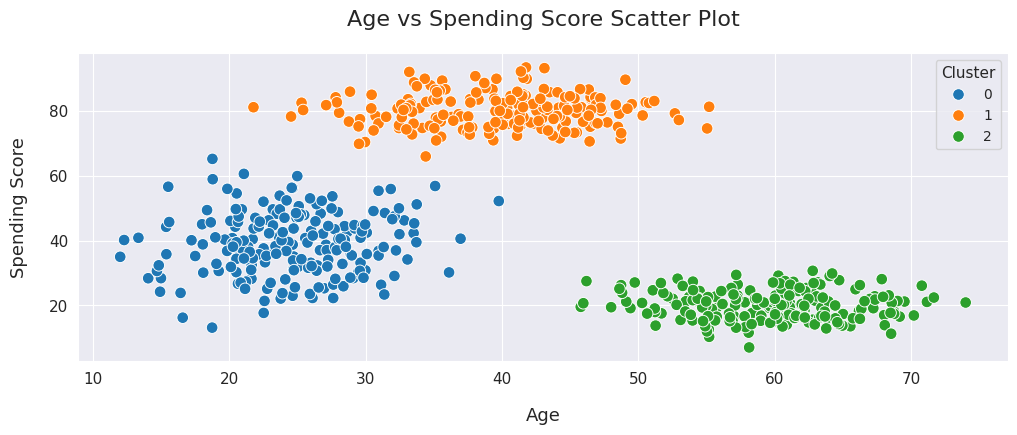

In [27]:
plt.figure(figsize=(12, 4))
sns.set_style("darkgrid")

sns.scatterplot(
    data=df,
    x="Age",
    y="SpendingScore",
    hue=spectral.labels_,
    palette="tab10",
    s=70
)
'''
plt.scatter(
    [x for x, y in spectral.cluster_centers_],
    [y for x, y in spectral.cluster_centers_],
    marker="X",
    color="red",
    s=150
)'''

plt.title("Age vs Spending Score Scatter Plot", fontsize=16, pad=20)
plt.xlabel("Age", fontsize=13, labelpad=15)
plt.ylabel("Spending Score", fontsize=13, labelpad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(title="Cluster", fontsize=10, title_fontsize=11)

plt.show()

Suppose we are given 50 people with their age and spending score values. Between scheduled re-runs, using predict() is a practical way to keep our previous clustering interpretation consistent.     

After fitting K-Means, the learned centroids represent the current cluster structure we have already analyzed and given business meaning to; when a small batch of new records arrives, predict() simply assigns each new point to the nearest existing centroid, so we can evaluate them under the same cluster definitions until the next re-fit.     

This only works reliably if we apply the exact same preprocessing (scaling/encoding and feature order) used during training. It’s also good practice to monitor the distance to the nearest centroid: if new points are unusually far from all centroids, flag them for review instead of forcing an assignment, because this can indicate drift or an emerging new pattern that should be reassessed at the next re-run.

In [9]:
new_customers = pd.DataFrame(np.random.normal(loc=[45, 40], scale=[20, 20], size=(50, 2)), 
                             columns=["Age", "SpendingScore"])

new_customers.sample()

,Age,SpendingScore
8,21.146,34.821


`kmeans.predict` is a bound method (the fitted `kmeans` instance is implicitly passed as `self`), so this assigns each new customer to the nearest learned centroid.

In [10]:
new_customers_labels = spectral.predict(new_customers)

AttributeError: 'SpectralClustering' object has no attribute 'predict'

let's visualize the new customers in 2D and color the each point according to their cluster.

In [11]:
plt.figure(figsize=(12, 4))
sns.set_style("darkgrid")

sns.scatterplot(
    data=new_customers,
    x="Age",
    y="SpendingScore",
    hue=new_customers_labels,
    palette="tab10",
    s=70
)

plt.scatter(
    [x for x, y in kmeans.cluster_centers_],
    [y for x, y in kmeans.cluster_centers_],
    marker="X",
    color="red",
    s=100
)

plt.title("Age vs Spending Score Scatter Plot", fontsize=16, pad=20)
plt.xlabel("Age", fontsize=13, labelpad=15)
plt.ylabel("Spending Score", fontsize=13, labelpad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(title="Cluster", fontsize=10, title_fontsize=11)

plt.show()

NameError: name 'new_customers_labels' is not defined

<Figure size 1200x400 with 0 Axes>